**LAB Assingment - 2 : AI in Healthcare**

In [ ]:
# 1. IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# Display settings
pd.set_option('display.max_columns', None)

In [ ]:
# 2. DATASET ACQUISITION
file_path = "x/content/archive.zip"

In [ ]:
file_path = "/content/archive.zip"

# 3. LOAD DATASET

df = pd.read_csv(file_path)

print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
# 4. SUMMARIZE DATASET

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nDataset Information:")
df.info()

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Number of rows: 299
Number of columns: 13

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes

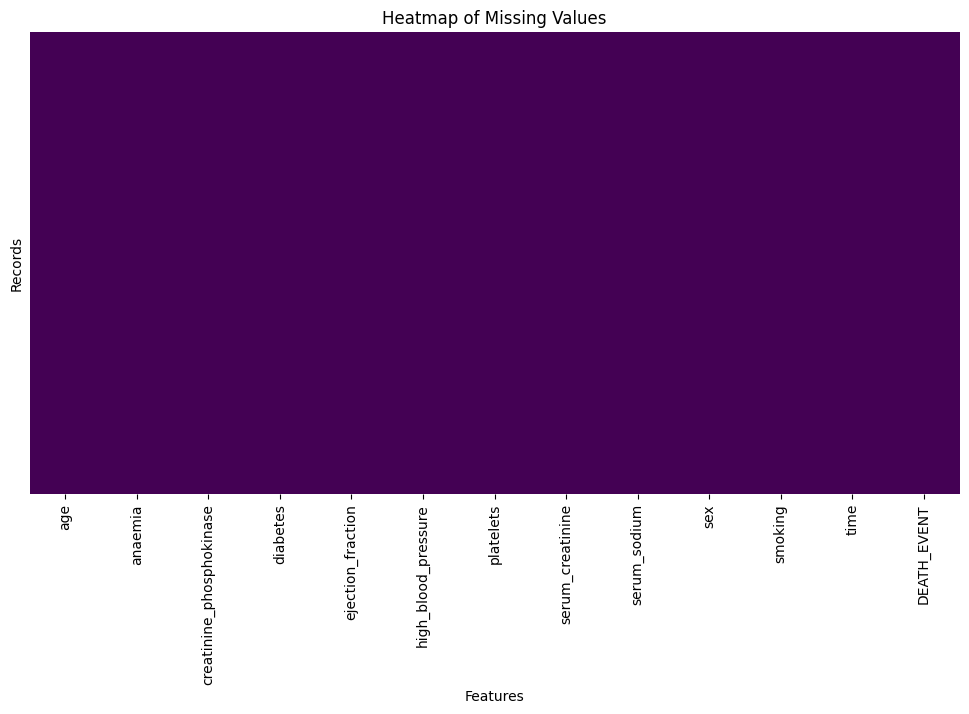

In [ ]:
# 5. VISUALIZE MISSING VALUES

plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Heatmap of Missing Values")
plt.xlabel("Features")
plt.ylabel("Records")
plt.show()

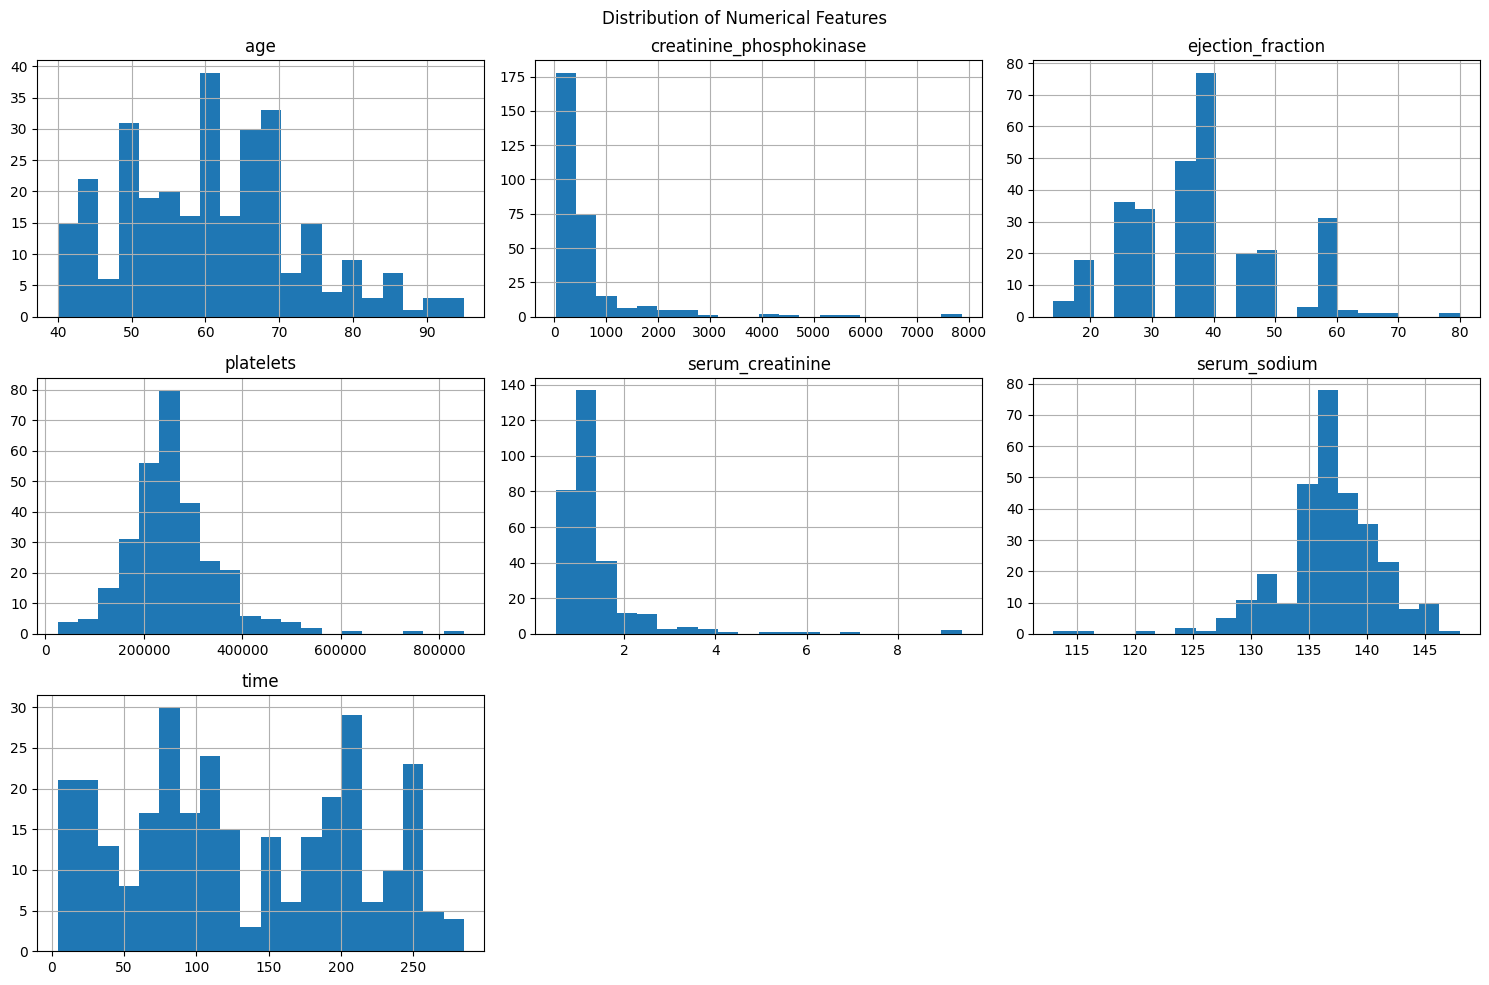

In [ ]:
# 6. DISTRIBUTION OF NUMERICAL FEATURES

numerical_features = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

# Histograms
df[numerical_features].hist(
    figsize=(15, 10),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

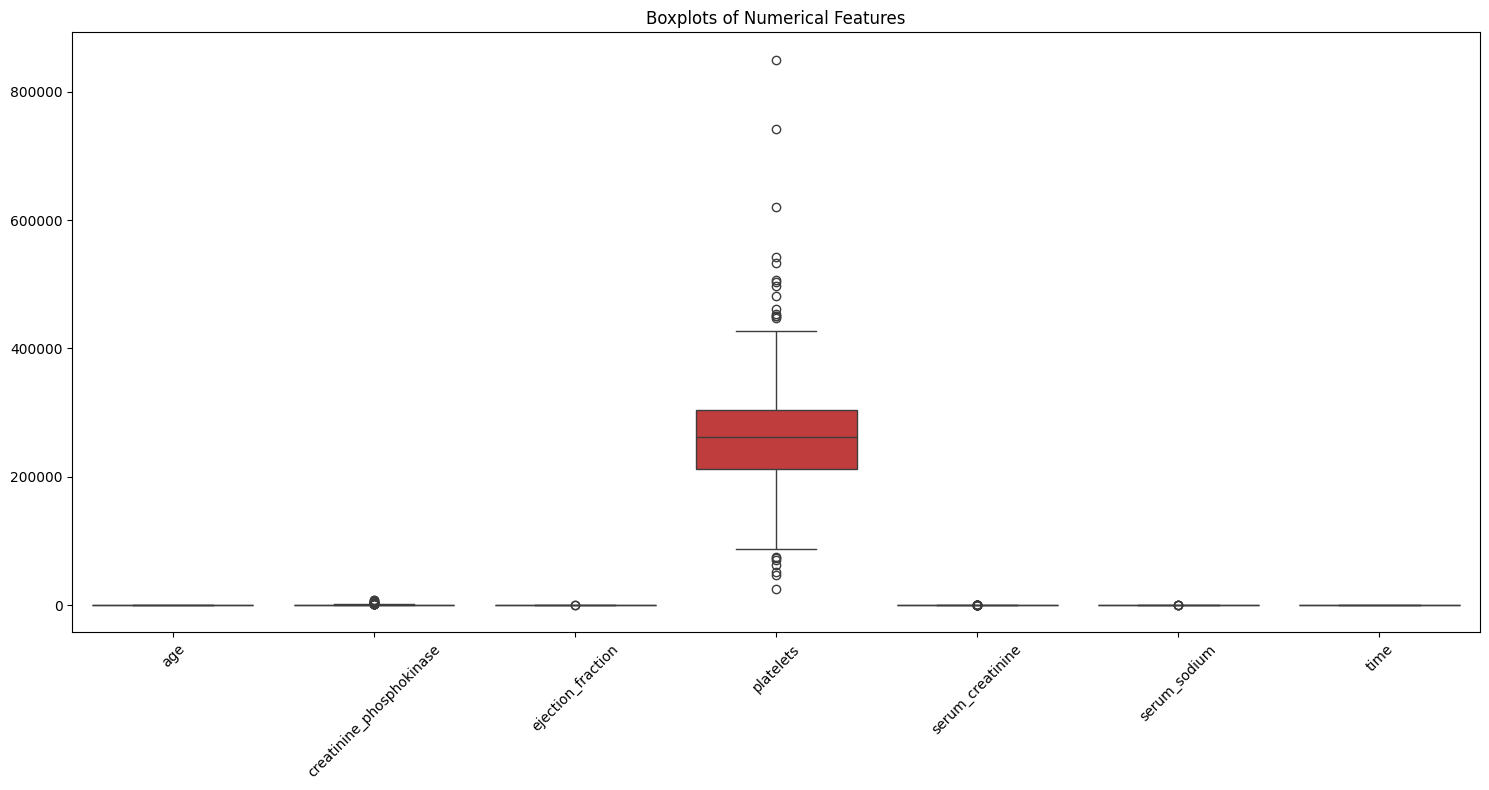

In [ ]:
# 7. BOX PLOTS FOR NUMERICAL FEATURS

plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numerical_features])

plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.tight_layout()
plt.show()

In [ ]:
# 8. IMPUTE MISSING VALUES

# Numerical columns
numerical_columns = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Do not include target variable in imputation
if 'DEATH_EVENT' in numerical_columns:
    numerical_columns.remove('DEATH_EVENT')

# Numerical features -> median imputation
for col in numerical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Categorical columns
categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

# Categorical features -> mode imputation
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [ ]:
# 9. REMOVE OUTLIERS USING IQR METHOD

df_clean = df.copy()

def remove_outliers_iqr(data, columns):
    cleaned_data = data.copy()

    for column in columns:
        Q1 = cleaned_data[column].quantile(0.25)
        Q3 = cleaned_data[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        cleaned_data = cleaned_data[
            (cleaned_data[column] >= lower_bound) &
            (cleaned_data[column] <= upper_bound)
        ]

    return cleaned_data


df_clean = remove_outliers_iqr(
    df_clean,
    numerical_features
)

print("Original number of rows:", len(df))
print("Rows after removing outliers:", len(df_clean))
print("Number of rows removed:", len(df) - len(df_clean))

Original number of rows: 299
Rows after removing outliers: 224
Number of rows removed: 75


In [ ]:
# 10. CHECK AND CORRECT INVALID ENTRIES

# Check for negative age
print("Negative ages:", (df_clean['age'] < 0).sum())

# Check ejection fraction
print(
    "Invalid ejection fraction:",
    ((df_clean['ejection_fraction'] < 0) |
     (df_clean['ejection_fraction'] > 100)).sum()
)

# Check binary columns
binary_columns = [
    'anaemia',
    'diabetes',
    'high_blood_pressure',
    'sex',
    'smoking',
    'DEATH_EVENT'
]

for col in binary_columns:
    print(
        col,
        "unique values:",
        df_clean[col].unique()
    )

# Correct invalid age values if any
df_clean.loc[df_clean['age'] < 0, 'age'] = df_clean['age'].median()

# Correct invalid ejection fraction if any
df_clean.loc[
    (df_clean['ejection_fraction'] < 0) |
    (df_clean['ejection_fraction'] > 100),
    'ejection_fraction'
] = df_clean['ejection_fraction'].median()

print("\nConsistency checking completed.")

Negative ages: 0
Invalid ejection fraction: 0
anaemia unique values: [0 1]
diabetes unique values: [0 1]
high_blood_pressure unique values: [1 0]
sex unique values: [1 0]
smoking unique values: [0 1]
DEATH_EVENT unique values: [1 0]

Consistency checking completed.


In [ ]:
# 11. CREATE AGE GROUP

df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 40, 60, np.inf],
    labels=['<40', '40-60', '>60'],
    right=False
)

print(df_clean[['age', 'age_group']].head(10))

     age age_group
0   75.0       >60
2   65.0       >60
3   50.0     40-60
5   90.0       >60
6   75.0       >60
8   65.0       >60
11  62.0       >60
12  45.0     40-60
13  50.0     40-60
14  49.0     40-60


In [ ]:
# 12. CREATE RISK SCORE

# Normalize the two required variables first
ef_norm = (
    (df_clean['ejection_fraction'] -
     df_clean['ejection_fraction'].min()) /
    (df_clean['ejection_fraction'].max() -
     df_clean['ejection_fraction'].min())
)

creatinine_norm = (
    (df_clean['serum_creatinine'] -
     df_clean['serum_creatinine'].min()) /
    (df_clean['serum_creatinine'].max() -
     df_clean['serum_creatinine'].min())
)

# Product-based risk score
df_clean['risk_score'] = ef_norm * creatinine_norm

print(df_clean[['ejection_fraction',
                'serum_creatinine',
                'risk_score']].head())

   ejection_fraction  serum_creatinine  risk_score
0                 20               1.9    0.101961
2                 20               1.3    0.054902
3                 20               1.9    0.101961
5                 40               2.1    0.509804
6                 15               1.2    0.007843


In [ ]:
# 13. ENCODE CATEGORICAL VARIABLES

# One-hot encode age_group
df_encoded = pd.get_dummies(
    df_clean,
    columns=['age_group'],
    dtype=int
)

print("Dataset after encoding:")
display(df_encoded.head())

print("\nNew columns:")
print(df_encoded.columns)

Dataset after encoding:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,75.0,0,582,0,20,1,265000.0,1.9,130,1,0,4,1,0.101961,0,0,1
2,65.0,0,146,0,20,0,162000.0,1.3,129,1,1,7,1,0.054902,0,0,1
3,50.0,1,111,0,20,0,210000.0,1.9,137,1,0,7,1,0.101961,0,1,0
5,90.0,1,47,0,40,1,204000.0,2.1,132,1,1,8,1,0.509804,0,0,1
6,75.0,1,246,0,15,0,127000.0,1.2,137,1,0,10,1,0.007843,0,0,1



New columns:
Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT', 'risk_score', 'age_group_<40', 'age_group_40-60',
       'age_group_>60'],
      dtype='object')


In [ ]:
# ------------------------------------------------------------
# 14. NORMALIZE NUMERICAL FEATURES
# ------------------------------------------------------------

features_to_scale = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

scaler = MinMaxScaler()

df_encoded[features_to_scale] = scaler.fit_transform(
    df_encoded[features_to_scale]
)

print("Normalized numerical features:")
display(df_encoded[features_to_scale].head())

Normalized numerical features:


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
0,0.636364,0.470990,0.117647,0.468852,0.866667,0.217391,0.000000
2,0.454545,0.098976,0.117647,0.131148,0.466667,0.173913,0.010676
3,0.181818,0.069113,0.117647,0.288525,0.866667,0.521739,0.010676
5,0.909091,0.014505,0.509804,0.268852,1.000000,0.304348,0.014235
6,0.636364,0.184300,0.019608,0.016393,0.400000,0.521739,0.021352


In [ ]:
# ------------------------------------------------------------
# 15. SUMMARY STATISTICS BEFORE CLEANING
# ------------------------------------------------------------

summary_before = df[numerical_features].agg(
    ['mean', 'median', 'std']
).T

print("Summary Statistics BEFORE Cleaning:")
display(summary_before)

Summary Statistics BEFORE Cleaning:


,mean,median,std
age,60.833893,60.0,11.894809
creatinine_phosphokinase,581.839465,250.0,970.287881
ejection_fraction,38.083612,38.0,11.834841
platelets,263358.029264,262000.0,97804.236869
serum_creatinine,1.393880,1.1,1.034510
serum_sodium,136.625418,137.0,4.412477
time,130.260870,115.0,77.614208


In [ ]:
# ------------------------------------------------------------
# 16. SUMMARY STATISTICS AFTER CLEANING
# ------------------------------------------------------------

summary_after = df_clean[numerical_features].agg(
    ['mean', 'median', 'std']
).T

print("Summary Statistics AFTER Cleaning:")
display(summary_after)

Summary Statistics AFTER Cleaning:


,mean,median,std
age,60.809527,60.0,11.946085
creatinine_phosphokinase,336.941964,212.0,279.521085
ejection_fraction,38.178571,38.0,11.710801
platelets,255865.190045,262500.0,67153.749051
serum_creatinine,1.128571,1.1,0.327794
serum_sodium,137.044643,137.0,3.806740
time,132.651786,120.0,76.579770


In [ ]:
# ------------------------------------------------------------
# 16. SUMMARY STATISTICS AFTER CLEANING
# ------------------------------------------------------------

summary_after = df_clean[numerical_features].agg(
    ['mean', 'median', 'std']
).T

print("Summary Statistics AFTER Cleaning:")
display(summary_after)

Summary Statistics AFTER Cleaning:


,mean,median,std
age,60.809527,60.0,11.946085
creatinine_phosphokinase,336.941964,212.0,279.521085
ejection_fraction,38.178571,38.0,11.710801
platelets,255865.190045,262500.0,67153.749051
serum_creatinine,1.128571,1.1,0.327794
serum_sodium,137.044643,137.0,3.806740
time,132.651786,120.0,76.579770


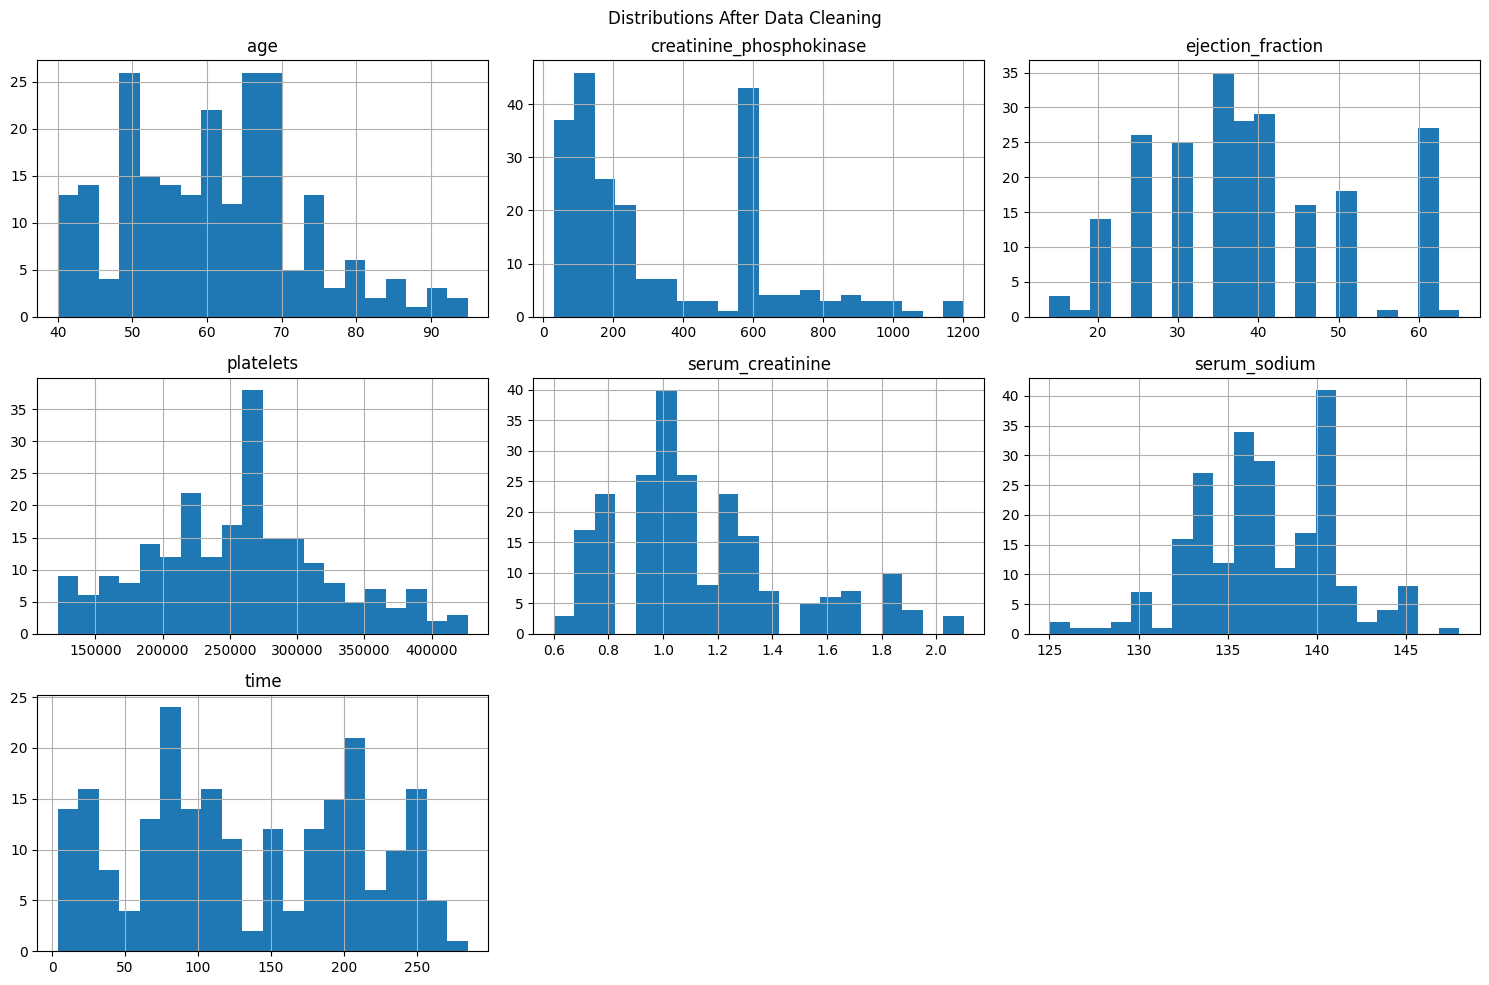

In [ ]:
# ------------------------------------------------------------
# 18. VALIDATE CLEANED DATA
# ------------------------------------------------------------

df_clean[numerical_features].hist(
    figsize=(15, 10),
    bins=20
)

plt.suptitle("Distributions After Data Cleaning")
plt.tight_layout()
plt.show()

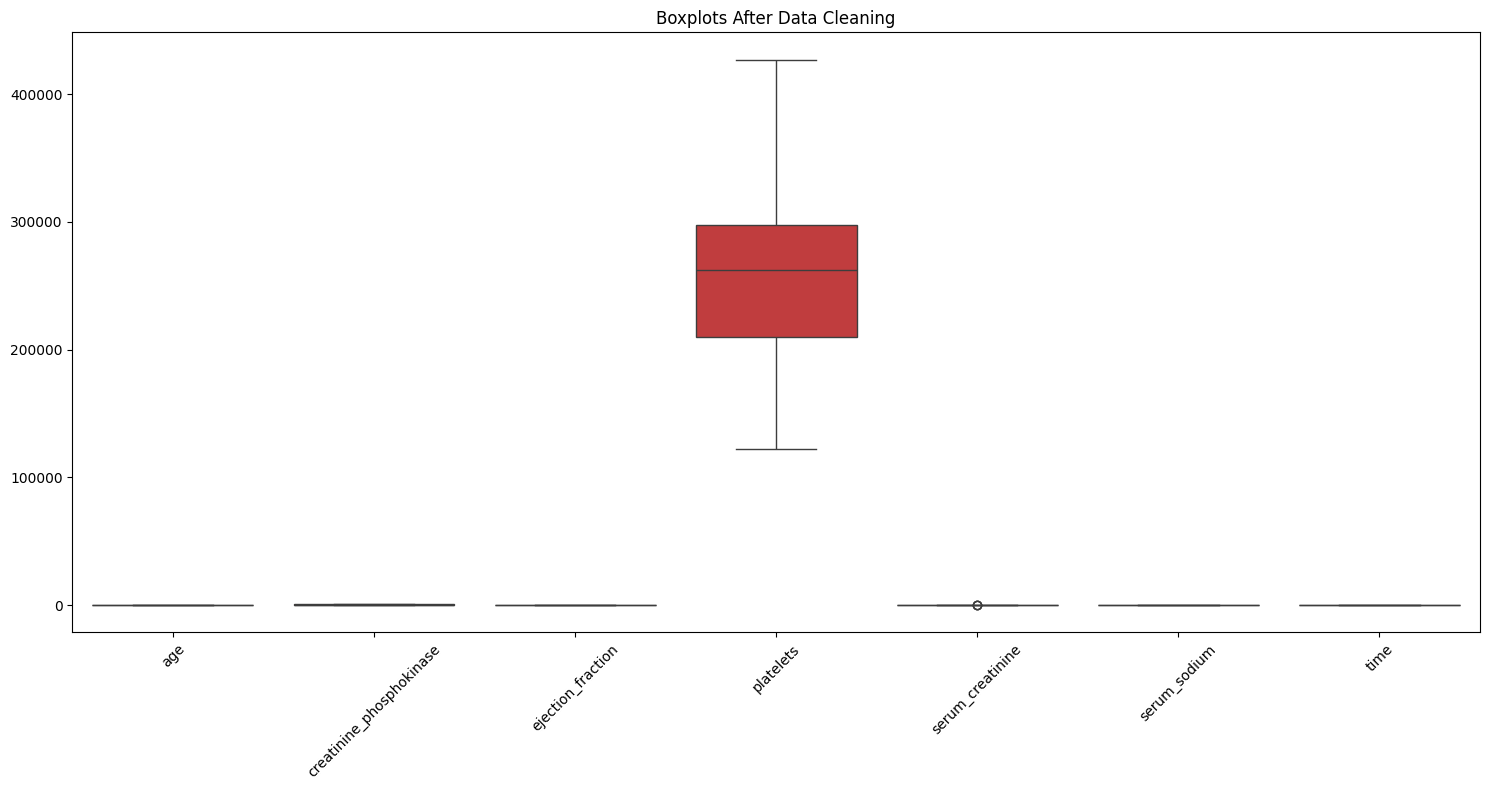

In [ ]:
# ------------------------------------------------------------
# 19. BOXPLOTS AFTER CLEANING
# ------------------------------------------------------------

plt.figure(figsize=(15, 8))

sns.boxplot(
    data=df_clean[numerical_features]
)

plt.xticks(rotation=45)
plt.title("Boxplots After Data Cleaning")
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# 20. FINAL MISSING VALUE CHECK
# ------------------------------------------------------------

print("Missing values after complete cleaning:")

missing_values = df_encoded.isnull().sum()

print(missing_values)

print(
    "\nTotal missing values:",
    df_encoded.isnull().sum().sum()
)

if df_encoded.isnull().sum().sum() == 0:
    print("\nSUCCESS: No missing values remain.")
else:
    print("\nSome missing values still remain.")

Missing values after complete cleaning:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_<40               0
age_group_40-60             0
age_group_>60               0
dtype: int64

Total missing values: 0

SUCCESS: No missing values remain.


In [ ]:
# ------------------------------------------------------------
# 21. DISPLAY FINAL DATASET
# ------------------------------------------------------------

print("Final cleaned dataset:")
display(df_encoded.head())

print("\nFinal shape:")
print(df_encoded.shape)

Final cleaned dataset:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,0.636364,0,0.470990,0,0.117647,1,0.468852,0.866667,0.217391,1,0,0.000000,1,0.101961,0,0,1
2,0.454545,0,0.098976,0,0.117647,0,0.131148,0.466667,0.173913,1,1,0.010676,1,0.054902,0,0,1
3,0.181818,1,0.069113,0,0.117647,0,0.288525,0.866667,0.521739,1,0,0.010676,1,0.101961,0,1,0
5,0.909091,1,0.014505,0,0.509804,1,0.268852,1.000000,0.304348,1,1,0.014235,1,0.509804,0,0,1
6,0.636364,1,0.184300,0,0.019608,0,0.016393,0.400000,0.521739,1,0,0.021352,1,0.007843,0,0,1



Final shape:
(224, 17)


In [ ]:
# ------------------------------------------------------------
# 22. SAVE CLEANED DATASET
# ------------------------------------------------------------

df_encoded.to_csv(
    "heart_failure_cleaned_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
